<a href="https://colab.research.google.com/github/uldopp/TMON/blob/main/PROJECT/PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import make_scorer
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import OrdinalEncoder

In [13]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import cross_val_score

from sklearn import metrics
from collections import Counter
# импорт нужных библиотек
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes  # подключаем датасет из sklearn
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

In [41]:
# сразу напишем код функции, которая будет вычислять все нужные метрики

def Reg_Models_Evaluation_Metrics (model,X_train,y_train,X_test,y_test,y_pred):
    cv_score = cross_val_score(estimator = model, X = X_train, y = y_train, cv = 10)

    # Calculating Adjusted R-squared
    r2 = model.score(X_test, y_test)
    # Number of observations is the shape along axis 0
    n = X_test.shape[0]
    # Number of features (predictors, p) is the shape along axis 1
    p = X_test.shape[1]
    # Adjusted R-squared formula
    adjusted_r2 = 1-(1-r2)*(n-1)/(n-p-1)
    RMSE = np.sqrt(metrics.mean_squared_error(y_test, y_pred))
    R2 = model.score(X_test, y_test)
    CV_R2 = cv_score.mean()

    print(f'RMSE:  {round(RMSE,4)}\n  R2: {round(R2,4)}\n Adjusted R2: {round(adjusted_r2, 4)}\n Cross Validated R2: {round(cv_score.mean(),4)}')
    return R2, adjusted_r2, CV_R2, RMSE

In [3]:
df = pd.read_excel('StressLevelDataset.xlsx')

In [4]:
df.head()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,...,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,...,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,...,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,...,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,...,3,4,3,1,2,1,5,0,5,1


Набор данных содержит около 20 функций, которые оказывают наибольшее влияние на стресс студента. Характеристики отбираются научно с учётом пяти основных факторов: психологический, физиологический, социальный, экологический и академический.
1.   Психологические факторы:
*   anxiety_level - уровень тревожности
*   self_esteem - самооценка
*   mental_health_history - наличие проблем с психическим здоровьем
*   depression - уровень депрессии
2.   Физические факторы:
*   headache - головные боли
*   blood_pressure - артериальное давление
*   sleep_quality - качество сна
*   breathing_problem - проблемы с дыханием
3.   Социальные факторы:
*   noise_level - уровень шума
*   living_conditions - условия проживания
*   safety - ощущение безопасности
*   basic_needs - удовлетворение базовым потребностей
*   social_support - социальная поддержка
*   peer_pressure - давление со стороны сверстников
*   bullyng - буллинг
4.   Академические факторы:
*   academic_performance - академическая успеваемость
*   study_load - учебная нагрузка
*   teacher_student_relationship - отношение между преподавателями и студентами
*   future_career_concerns - беспокойство о будущей карьере
*   extracurricular_activities - внеучебная активность
5.   Результат:
*   stress_level - уровень стресса






In [16]:
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")

Размер датасета: 1100 строк, 21 столбцов


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   anxiety_level                 1100 non-null   int64
 1   self_esteem                   1100 non-null   int64
 2   mental_health_history         1100 non-null   int64
 3   depression                    1100 non-null   int64
 4   headache                      1100 non-null   int64
 5   blood_pressure                1100 non-null   int64
 6   sleep_quality                 1100 non-null   int64
 7   breathing_problem             1100 non-null   int64
 8   noise_level                   1100 non-null   int64
 9   living_conditions             1100 non-null   int64
 10  safety                        1100 non-null   int64
 11  basic_needs                   1100 non-null   int64
 12  academic_performance          1100 non-null   int64
 13  study_load                    110

In [9]:
df.describe()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
count,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,...,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000
mean,11.063636,17.777273,0.492727,12.555455,2.508182,2.181818,2.660000,2.753636,2.649091,2.518182,...,2.772727,2.772727,2.621818,2.648182,2.649091,1.881818,2.734545,2.767273,2.617273,0.996364
std,6.117558,8.944599,0.500175,7.727008,1.409356,0.833575,1.548383,1.400713,1.328127,1.119208,...,1.433761,1.414594,1.315781,1.384579,1.529375,1.047826,1.425265,1.417562,1.530958,0.821673
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,11.000000,0.000000,6.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000,2.000000,1.000000,0.000000
50%,11.000000,19.000000,0.000000,12.000000,3.000000,2.000000,2.500000,3.000000,3.000000,2.000000,...,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.500000,3.000000,1.000000
75%,16.000000,26.000000,1.000000,19.000000,3.000000,3.000000,4.000000,4.000000,3.000000,3.000000,...,4.000000,4.000000,3.000000,4.000000,4.000000,3.000000,4.000000,4.000000,4.000000,2.000000
max,21.000000,30.000000,1.000000,27.000000,5.000000,3.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,5.000000,5.000000,5.000000,2.000000


In [17]:
print(f"\nПропущенные значения:\n{df.isnull().sum()}")


Пропущенные значения:
anxiety_level                   0
self_esteem                     0
mental_health_history           0
depression                      0
headache                        0
blood_pressure                  0
sleep_quality                   0
breathing_problem               0
noise_level                     0
living_conditions               0
safety                          0
basic_needs                     0
academic_performance            0
study_load                      0
teacher_student_relationship    0
future_career_concerns          0
social_support                  0
peer_pressure                   0
extracurricular_activities      0
bullying                        0
stress_level                    0
dtype: int64


In [19]:
# ==================== 3. АНАЛИЗ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ ====================
print("\n" + "="*80)
print("3. АНАЛИЗ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ (stress_level)")
print("="*80)

# Распределение stress_level
print(f"\nРаспределение stress_level:\n{df['stress_level'].value_counts()}")
print(f"\nПроцентное распределение:\n{df['stress_level'].value_counts(normalize=True) * 100}")




3. АНАЛИЗ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ (stress_level)

Распределение stress_level:
stress_level
0    373
2    369
1    358
Name: count, dtype: int64

Процентное распределение:
stress_level
0    33.909091
2    33.545455
1    32.545455
Name: proportion, dtype: float64


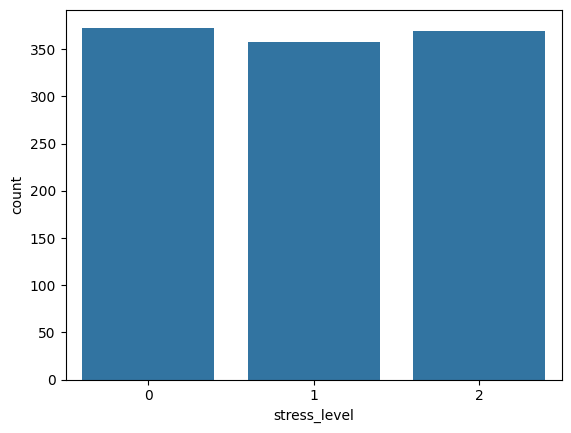

In [22]:
sns.countplot(x=df['stress_level']);

4. РАСПРЕДЕЛЕНИЕ ПРИЗНАКОВ


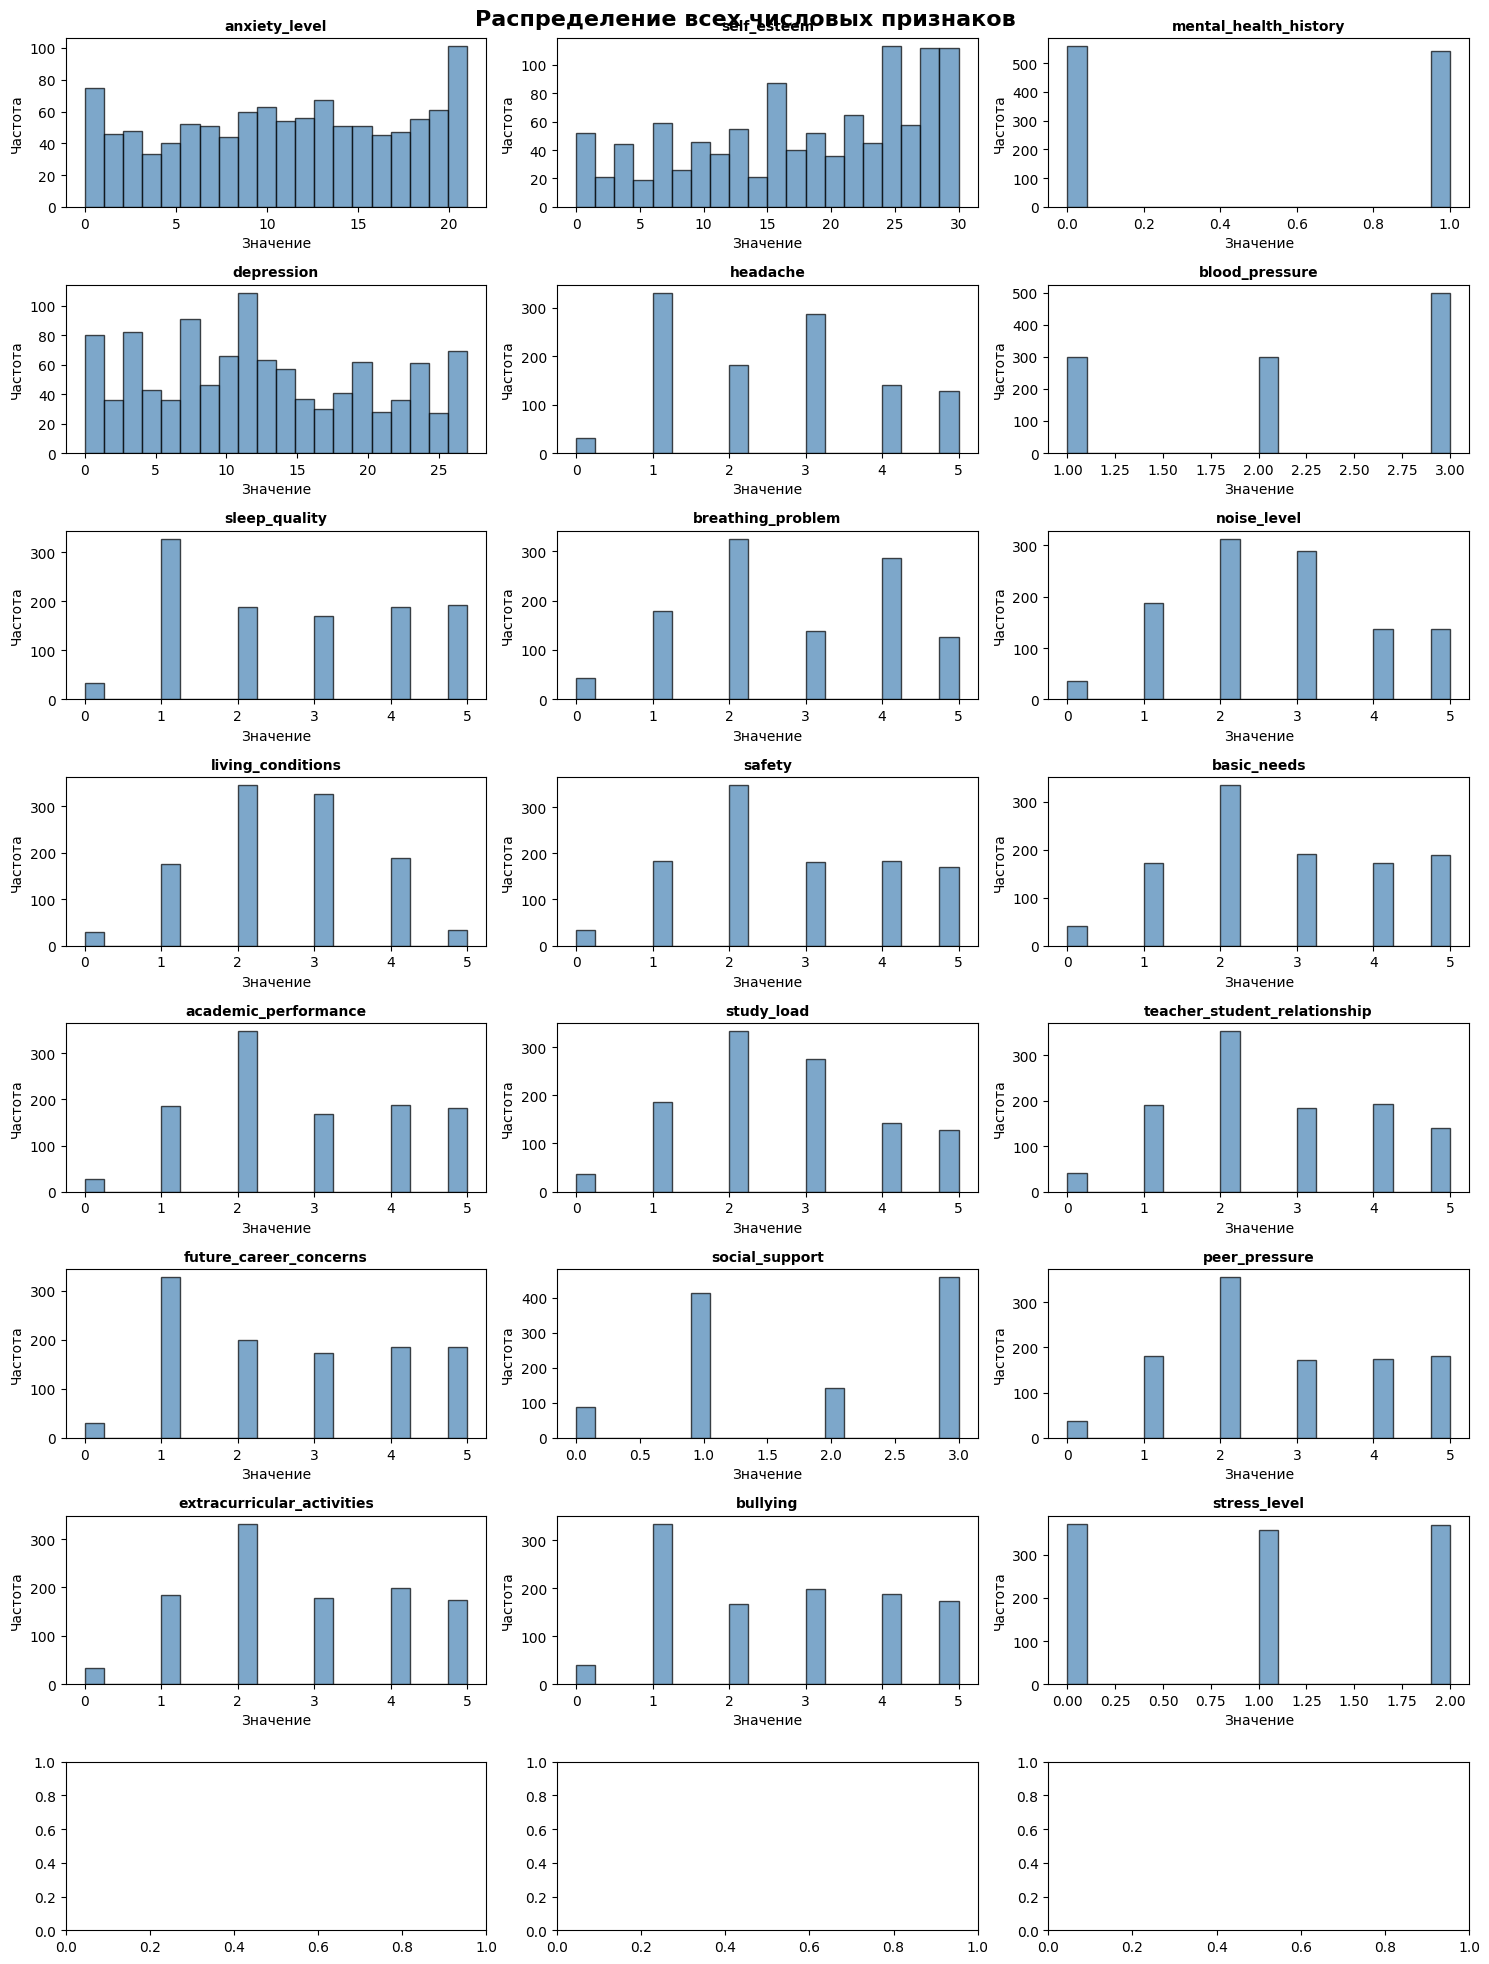

In [33]:
print("4. РАСПРЕДЕЛЕНИЕ ПРИЗНАКОВ")
print("="*80)

# Разделяем признаки на категории
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()

# Гистограммы для числовых признаков
fig, axes = plt.subplots(8, 3, figsize=(15, 20))
axes = axes.flatten()

for idx, feature in enumerate(numeric_features):
    axes[idx].hist(df[feature], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
    axes[idx].set_title(feature, fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Значение')
    axes[idx].set_ylabel('Частота')

plt.suptitle('Распределение всех числовых признаков', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('features_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


5. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ


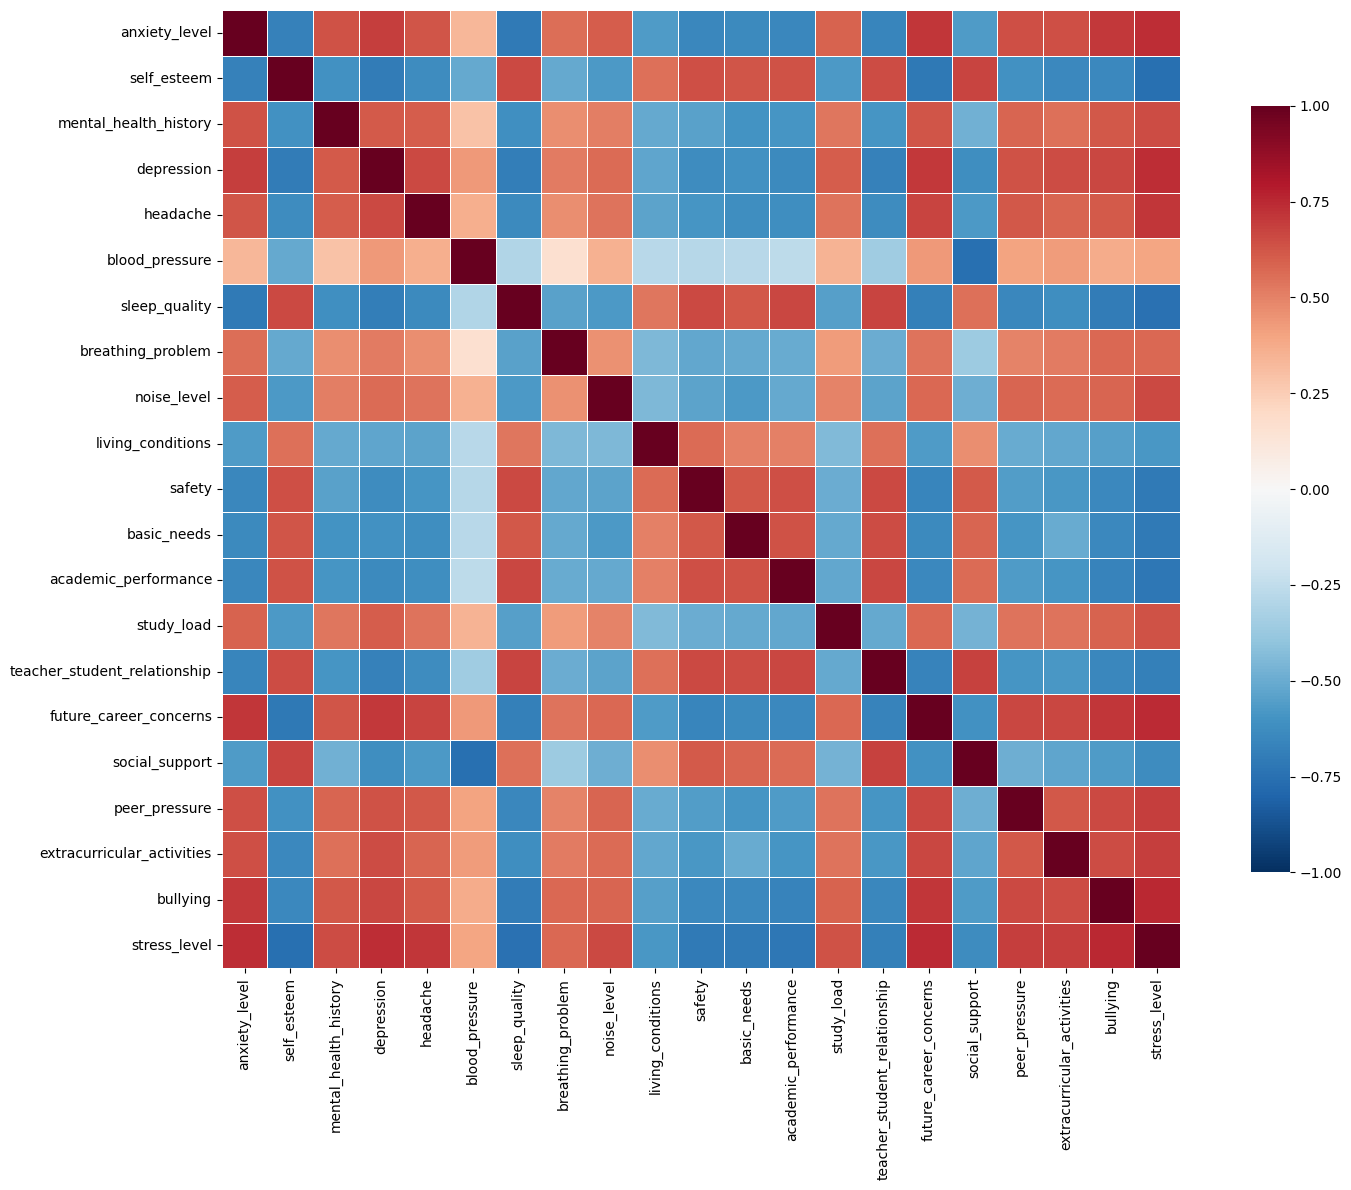

In [30]:
# ================== 5. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ ==================
print("\n" + "="*80)
print("5. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ")
print("="*80)

# Вычисляем корреляцию с target
correlations = df.corr()['stress_level'].sort_values(ascending=False)

# ПОЛНАЯ тепловая карта корреляций (без маски)
plt.figure(figsize=(16, 12))

# Полная матрица корреляций (без маски)
sns.heatmap(df.corr(),
            annot=False,           # можно изменить на True, чтобы видеть значения
            cmap='RdBu_r',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1)       # фиксированный диапазон для корреляций
plt.tight_layout()
plt.savefig('correlation_heatmap_full.png', dpi=300, bbox_inches='tight')
plt.show()

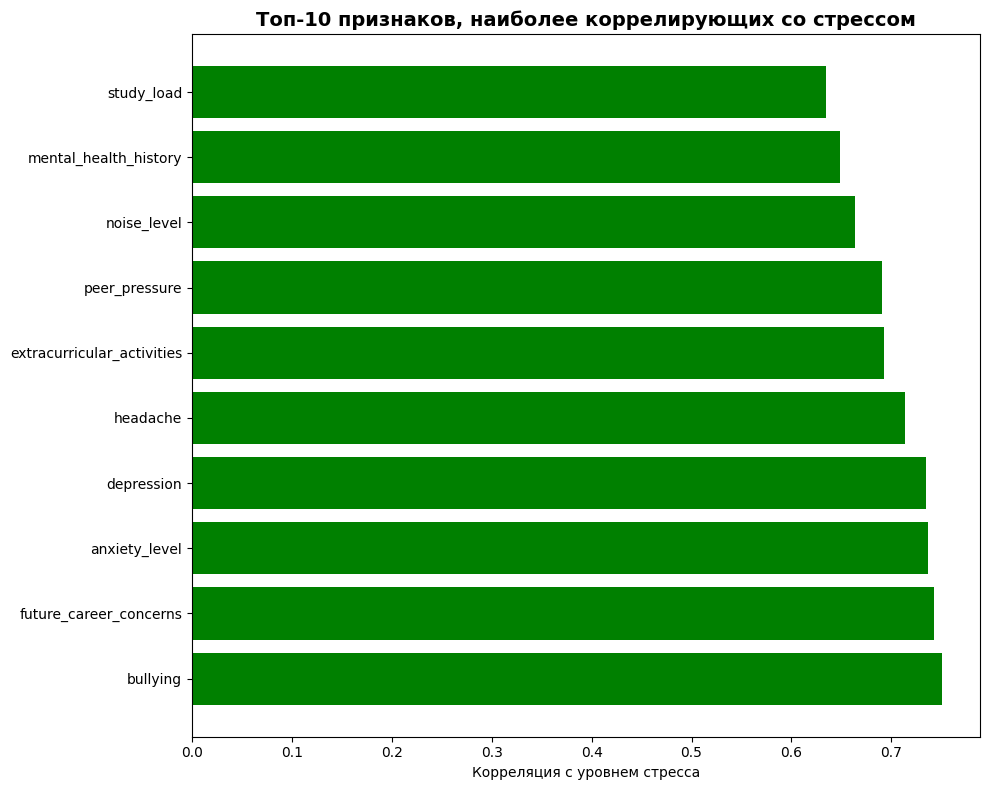

In [31]:
# Топ-10 признаков, наиболее коррелирующих со стрессом
plt.figure(figsize=(10, 8))
top_corr = correlations.drop('stress_level').head(10)
colors_corr = ['red' if x < 0 else 'green' for x in top_corr.values]
plt.barh(range(len(top_corr)), top_corr.values, color=colors_corr)
plt.yticks(range(len(top_corr)), top_corr.index)
plt.xlabel('Корреляция с уровнем стресса')
plt.title('Топ-10 признаков, наиболее коррелирующих со стрессом', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.savefig('top_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

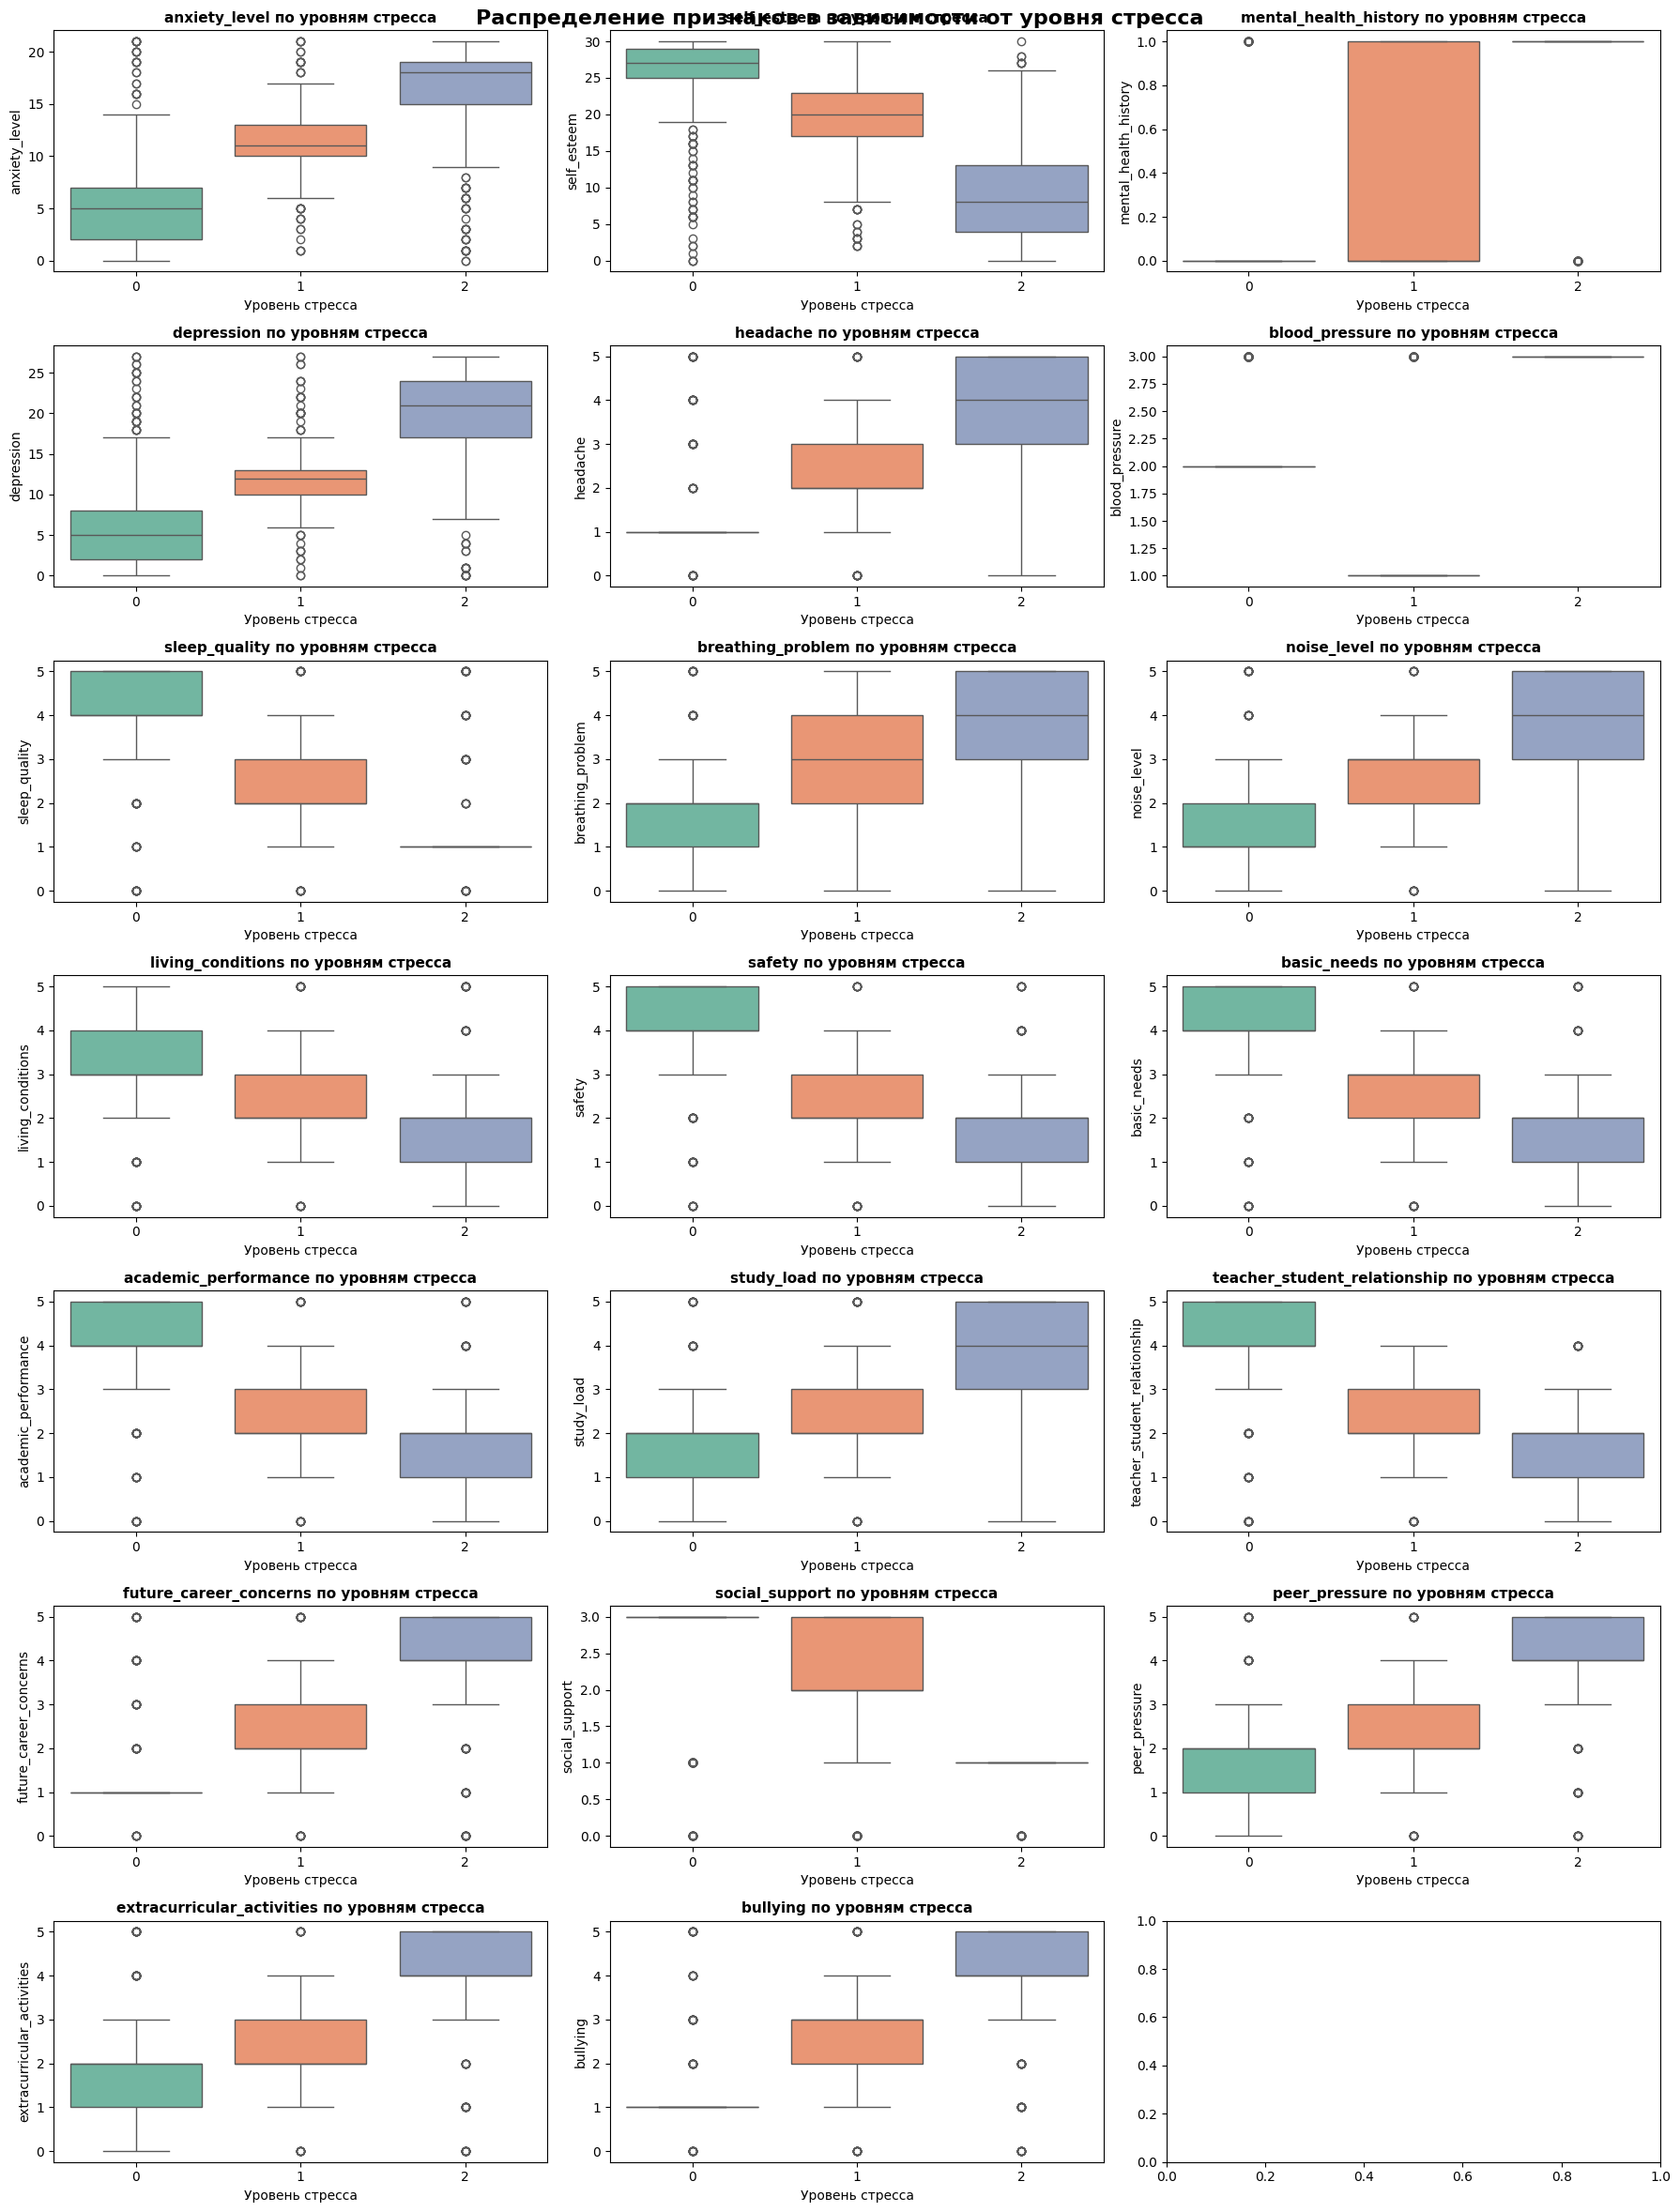

In [26]:
# Boxplot для всех признаков по уровням стресса
fig, axes = plt.subplots(7, 3, figsize=(18, 24))
axes = axes.flatten()

for idx, feature in enumerate(numeric_features):
    sns.boxplot(x='stress_level', y=feature, data=df, ax=axes[idx], palette='Set2')
    axes[idx].set_title(f'{feature} по уровням стресса', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Уровень стресса')
    axes[idx].set_ylabel(feature)

plt.suptitle('Распределение признаков в зависимости от уровня стресса', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('features_by_stress.png', dpi=300, bbox_inches='tight')
plt.show()


In [34]:
# подготавливаем датасет к обучению
X = df.drop(['stress_level'], axis=1)
y = df['stress_level']
print(f'X shape: {X.shape} | y shape: {y.shape} ')

X shape: (1100, 20) | y shape: (1100,) 


In [77]:
# делим датасет на трейн и тест

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=15)

In [78]:
from sklearn.linear_model import LinearRegression

# Create a linear regression model
modelLR = LinearRegression()

# Fit the model to the data
modelLR.fit(X_train, y_train)

# Predict the response for a new data point
y_pr_LR = modelLR.predict(X_test)

In [79]:
_ = Reg_Models_Evaluation_Metrics(modelLR, X_train, y_train, X_test, y_test, y_pr_LR)


RMSE:  0.4001
  R2: 0.7574
 Adjusted R2: 0.7417
 Cross Validated R2: 0.7569


In [80]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=3, include_bias=False)

poly_features = poly.fit_transform(X)
X_p_train, X_p_test, y_p_train, y_p_test = train_test_split(poly_features, y, test_size=0.2, random_state=42)
# Create a linear regression model
modelPR = LinearRegression()

# Fit the model to the data
modelPR.fit(X_p_train, y_p_train)

# Predict the response for a new data point
y_pr_PR = modelPR.predict(X_p_test)

_ = Reg_Models_Evaluation_Metrics(modelPR, X_p_train, y_p_train, X_p_test, y_p_test, y_pr_PR)

RMSE:  0.3872
  R2: 0.7755
 Adjusted R2: 1.0317
 Cross Validated R2: 0.7632


In [81]:
from sklearn.tree import DecisionTreeRegressor

# Create a stepwise regression model
modelDT = DecisionTreeRegressor()

# Fit the model to the data
modelDT.fit(X_train, y_train)

# Predict the response for a new data point
y_dt_pred = modelDT.predict(X_test)
_ = Reg_Models_Evaluation_Metrics(modelDT, X_train, y_train, X_test, y_test, y_dt_pred)


RMSE:  0.5135
  R2: 0.6006
 Adjusted R2: 0.5747
 Cross Validated R2: 0.6677


In [82]:
from sklearn.ensemble import RandomForestRegressor

# Create a stepwise regression model
modelRF = RandomForestRegressor(n_estimators=100)

# Fit the model to the data
modelRF.fit(X_train, y_train)

# Predict the response for a new data point
y_rf_pred = modelRF.predict(X_test)


_ = Reg_Models_Evaluation_Metrics(modelRF, X_train, y_train, X_test, y_test, y_rf_pred)

RMSE:  0.3807
  R2: 0.7804
 Adjusted R2: 0.7661
 Cross Validated R2: 0.786


In [83]:
from sklearn.svm import SVR

# Create a support vector regression model
modelSVR = SVR(kernel='linear')

modelSVR.fit(X_train, y_train)

# Predict the response for a new data point
y_rf_pred = modelSVR.predict(X_test)


_ = Reg_Models_Evaluation_Metrics(modelSVR, X_train, y_train, X_test, y_test, y_rf_pred)

RMSE:  0.392
  R2: 0.7672
 Adjusted R2: 0.7521
 Cross Validated R2: 0.769


In [84]:
from sklearn.svm import SVR

# Create a support vector regression model. Полиномиальное ядро
modelSVR = SVR(kernel='poly')

modelSVR.fit(X_train, y_train)

# Predict the response for a new data point
y_rf_pred = modelSVR.predict(X_test)


_ = Reg_Models_Evaluation_Metrics(modelSVR, X_train, y_train, X_test, y_test, y_rf_pred)

RMSE:  0.4096
  R2: 0.7458
 Adjusted R2: 0.7293
 Cross Validated R2: 0.7486


In [85]:

# Create a support vector regression model. Ядро - радиальная базисная функция
modelSVR = SVR(kernel='rbf')

modelSVR.fit(X_train, y_train)

# Predict the response for a new data point
y_rf_pred = modelSVR.predict(X_test)


_ = Reg_Models_Evaluation_Metrics(modelSVR, X_train, y_train, X_test, y_test, y_rf_pred)

RMSE:  0.4068
  R2: 0.7493
 Adjusted R2: 0.7331
 Cross Validated R2: 0.7576


In [50]:
from sklearn.linear_model import ElasticNet

# Create an elastic net regression model
modelEN = ElasticNet(alpha=0.1, l1_ratio=0.8)

# Fit the model to the data
modelEN.fit(X_train, y_train)

# Predict the response for a new data point
y_en_pred = modelEN.predict(X_test)

_ = Reg_Models_Evaluation_Metrics(modelEN, X_train, y_train, X_test, y_test, y_en_pred)

RMSE:  0.4253
  R2: 0.7328
 Adjusted R2: 0.706
 Cross Validated R2: 0.7462


In [56]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Загрузка данных
df = pd.read_excel('StressLevelDataset.xlsx')

# Отделяем признаки от целевой переменной
X = df.drop('stress_level', axis=1)
y = df['stress_level']

# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Создание датафрейма с масштабированными данными
df_scaled = pd.DataFrame(X_scaled, columns=X.columns)
df_scaled['stress_level'] = y.values

# Сохранение
df_scaled.to_excel('StressLevelDataset_Scaled.xlsx', index=False)

print("Масштабирование завершено!")
print(f"Размер данных: {df_scaled.shape}")

Масштабирование завершено!
Размер данных: (1100, 21)


In [58]:
df1 = pd.read_excel('StressLevelDataset_Scaled.xlsx')

In [60]:
df1.describe()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
count,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,...,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1100.000000
mean,-1.679465e-16,6.782453e-17,2.325413e-16,9.689219e-17,-9.527732e-17,3.488119e-16,6.782453e-17,1.929769e-16,1.614870e-16,1.162706e-16,...,-2.018587e-16,-2.220446e-16,2.163926e-16,9.850706e-17,1.695613e-16,-1.065814e-16,4.521636e-17,1.356491e-16,4.844610e-18,0.996364
std,1.000455e+00,1.000455e+00,1.000455e+00,1.000455e+00,1.000455e+00,1.000455e+00,1.000455e+00,1.000455e+00,1.000455e+00,1.000455e+00,...,1.000455e+00,1.000455e+00,1.000455e+00,1.000455e+00,1.000455e+00,1.000455e+00,1.000455e+00,1.000455e+00,1.000455e+00,0.821673
min,-1.809328e+00,-1.988391e+00,-9.855588e-01,-1.625618e+00,-1.780475e+00,-1.418416e+00,-1.718703e+00,-1.966776e+00,-1.995514e+00,-2.250991e+00,...,-1.934764e+00,-1.960979e+00,-1.993501e+00,-1.913497e+00,-1.732927e+00,-1.796742e+00,-1.919495e+00,-1.953023e+00,-1.710343e+00,0.000000
25%,-8.280983e-01,-7.580391e-01,-9.855588e-01,-8.487679e-01,-1.070608e+00,-1.418416e+00,-1.072574e+00,-5.382823e-01,-4.889489e-01,-4.632004e-01,...,-5.391964e-01,-5.465023e-01,-4.727998e-01,-4.683567e-01,-1.078768e+00,-8.419517e-01,-5.156090e-01,-5.415083e-01,-1.056860e+00,0.000000
50%,-1.040698e-02,1.367622e-01,-9.855588e-01,-7.191751e-02,3.491253e-01,-2.182179e-01,-1.033806e-01,1.759644e-01,2.643337e-01,-4.632004e-01,...,1.585872e-01,-5.465023e-01,-4.727998e-01,-4.683567e-01,-4.246087e-01,1.128389e-01,-5.156090e-01,-1.886297e-01,2.501057e-01,1.000000
75%,8.072843e-01,9.197134e-01,1.014653e+00,8.344079e-01,3.491253e-01,9.819805e-01,8.658128e-01,8.902111e-01,2.643337e-01,4.306951e-01,...,8.563708e-01,8.679743e-01,2.875508e-01,9.767832e-01,8.837095e-01,1.067629e+00,8.882770e-01,8.700062e-01,9.035886e-01,2.000000
max,1.624976e+00,1.367114e+00,1.014653e+00,1.870208e+00,1.768859e+00,9.819805e-01,1.511942e+00,1.604458e+00,1.770899e+00,2.218486e+00,...,1.554154e+00,1.575213e+00,1.808252e+00,1.699353e+00,1.537869e+00,1.067629e+00,1.590220e+00,1.575763e+00,1.557071e+00,2.000000


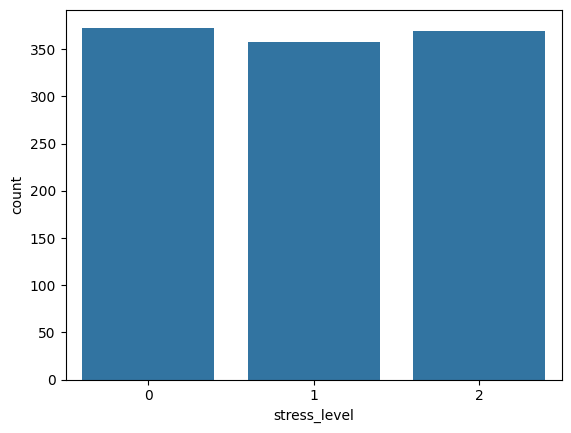

In [61]:
sns.countplot(x=df1['stress_level']);

In [62]:
# ==================== 3. АНАЛИЗ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ ====================
print("\n" + "="*80)
print("3. АНАЛИЗ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ (stress_level)")
print("="*80)

# Распределение stress_level
print(f"\nРаспределение stress_level:\n{df['stress_level'].value_counts()}")
print(f"\nПроцентное распределение:\n{df['stress_level'].value_counts(normalize=True) * 100}")




3. АНАЛИЗ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ (stress_level)

Распределение stress_level:
stress_level
0    373
2    369
1    358
Name: count, dtype: int64

Процентное распределение:
stress_level
0    33.909091
2    33.545455
1    32.545455
Name: proportion, dtype: float64


In [87]:
# подготавливаем датасет к обучению
X = df1.drop(['stress_level'], axis=1)
y = df1['stress_level']
print(f'X shape: {X.shape} | y shape: {y.shape} ')

X shape: (1100, 20) | y shape: (1100,) 


In [88]:
# делим датасет на трейн и тест

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=15)

In [89]:
from sklearn.linear_model import LinearRegression

# Create a linear regression model
modelLR = LinearRegression()

# Fit the model to the data
modelLR.fit(X_train, y_train)

# Predict the response for a new data point
y_pr_LR = modelLR.predict(X_test)

In [90]:
_ = Reg_Models_Evaluation_Metrics(modelLR, X_train, y_train, X_test, y_test, y_pr_LR)


RMSE:  0.4001
  R2: 0.7574
 Adjusted R2: 0.7417
 Cross Validated R2: 0.7569


In [91]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=3, include_bias=False)

poly_features = poly.fit_transform(X)
X_p_train, X_p_test, y_p_train, y_p_test = train_test_split(poly_features, y, test_size=0.3, random_state=42)
# Create a linear regression model
modelPR = LinearRegression()

# Fit the model to the data
modelPR.fit(X_p_train, y_p_train)

# Predict the response for a new data point
y_pr_PR = modelPR.predict(X_p_test)

_ = Reg_Models_Evaluation_Metrics(modelPR, X_p_train, y_p_train, X_p_test, y_p_test, y_pr_PR)

RMSE:  0.3704
  R2: 0.797
 Adjusted R2: 1.0464
 Cross Validated R2: 0.7356


In [92]:
from sklearn.tree import DecisionTreeRegressor

# Create a stepwise regression model
modelDT = DecisionTreeRegressor()

# Fit the model to the data
modelDT.fit(X_train, y_train)

# Predict the response for a new data point
y_dt_pred = modelDT.predict(X_test)

_ = Reg_Models_Evaluation_Metrics(modelDT, X_train, y_train, X_test, y_test, y_dt_pred)

RMSE:  0.4924
  R2: 0.6327
 Adjusted R2: 0.6089
 Cross Validated R2: 0.6843


In [93]:
from sklearn.ensemble import RandomForestRegressor

# Create a stepwise regression model
modelRF = RandomForestRegressor(n_estimators=100)

# Fit the model to the data
modelRF.fit(X_train, y_train)

# Predict the response for a new data point
y_rf_pred = modelRF.predict(X_test)


_ = Reg_Models_Evaluation_Metrics(modelRF, X_train, y_train, X_test, y_test, y_rf_pred)

RMSE:  0.3689
  R2: 0.7938
 Adjusted R2: 0.7805
 Cross Validated R2: 0.7846


In [94]:
from sklearn.svm import SVR

# Create a support vector regression model
modelSVR = SVR(kernel='linear')

modelSVR.fit(X_train, y_train)

# Predict the response for a new data point
y_rf_pred = modelSVR.predict(X_test)


_ = Reg_Models_Evaluation_Metrics(modelSVR, X_train, y_train, X_test, y_test, y_rf_pred)

RMSE:  0.392
  R2: 0.7672
 Adjusted R2: 0.7521
 Cross Validated R2: 0.769


In [95]:
from sklearn.svm import SVR

# Create a support vector regression model. Полиномиальное ядро
modelSVR = SVR(kernel='poly')

modelSVR.fit(X_train, y_train)

# Predict the response for a new data point
y_rf_pred = modelSVR.predict(X_test)


_ = Reg_Models_Evaluation_Metrics(modelSVR, X_train, y_train, X_test, y_test, y_rf_pred)

RMSE:  0.4096
  R2: 0.7458
 Adjusted R2: 0.7293
 Cross Validated R2: 0.7486


In [96]:
# Create a support vector regression model. Ядро - радиальная базисная функция
modelSVR = SVR(kernel='rbf')

modelSVR.fit(X_train, y_train)

# Predict the response for a new data point
y_rf_pred = modelSVR.predict(X_test)


_ = Reg_Models_Evaluation_Metrics(modelSVR, X_train, y_train, X_test, y_test, y_rf_pred)

RMSE:  0.4068
  R2: 0.7493
 Adjusted R2: 0.7331
 Cross Validated R2: 0.7576


In [97]:
from sklearn.linear_model import ElasticNet

# Create an elastic net regression model
modelEN = ElasticNet(alpha=0.1, l1_ratio=0.8)

# Fit the model to the data
modelEN.fit(X_train, y_train)

# Predict the response for a new data point
y_en_pred = modelEN.predict(X_test)

_ = Reg_Models_Evaluation_Metrics(modelEN, X_train, y_train, X_test, y_test, y_en_pred)

RMSE:  0.4082
  R2: 0.7475
 Adjusted R2: 0.7312
 Cross Validated R2: 0.7554
